In [1]:
import confidence_intervals
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
seed = 42
np.random.seed(seed)

In [3]:
def _validate_probability(value: float, name: str) -> None:
    if not 0 <= value <= 1:
        raise ValueError(f"{name} must be in [0, 1]; got {value!r}")
    

def generate_truncated_samples_gaussian(
    n: int,
    eps_1: float,
    eps_2: float,
    level: float,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate Gaussian samples with MCAR missingness and threshold corruption.

    Parameters
    ----------
    n:
        Number of samples to generate.
    eps_1:
        Probability that an observation is generated from a point mass on star.
    eps_2:
        Probability that an observation is subject to threshold corruption.
    level:
        Threshold used by the corruption step: only keep observations above this level.
    rng:
        Optional NumPy random number generator for reproducible simulations.
    """
    if n <= 0:
        raise ValueError(f"n must be positive; got {n!r}")
    _validate_probability(eps_1, "eps_1")
    _validate_probability(eps_2, "eps_2")
    _validate_probability(eps_1 + eps_2, "eps_1 + eps_2")

    random = np.random.default_rng() if rng is None else rng

    Z = random.normal(0, 1, n)
    labels = random.choice([0, 1, 2], size=n, p=[1-eps_1-eps_2, eps_1, eps_2])

    Z[labels == 1] = np.nan
    Z[labels == 2] = np.where(Z[labels == 2] >= level, Z[labels == 2], np.nan)

    return Z


In [4]:
level = 0.5
alpha = 0.05
rng = np.random.default_rng(42)

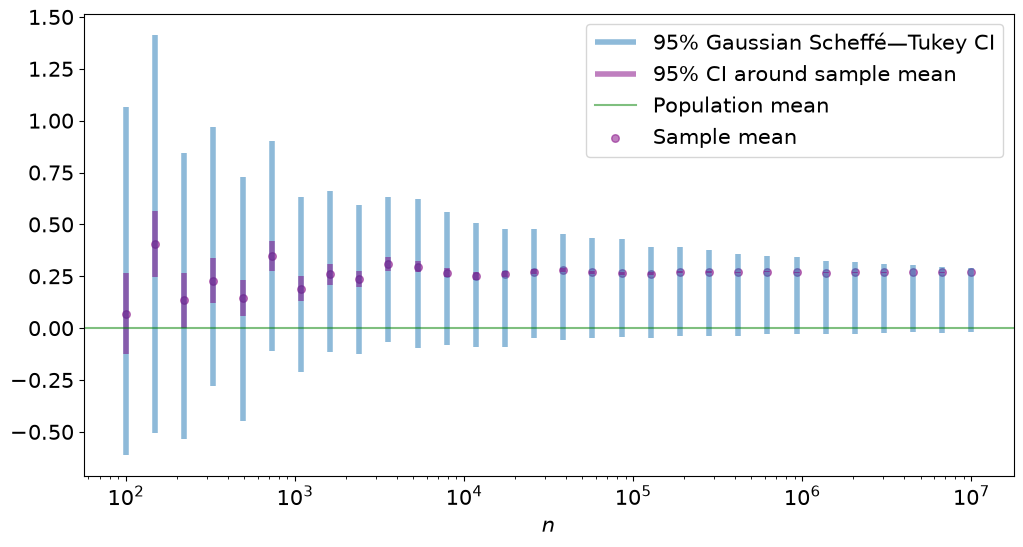

In [5]:
### Case (c), varying n

eps_1 = 0
eps_2 = 0.5

n_list = np.logspace(2, 7, num=30, dtype=int)
fixed_eps_dict = {}
opt_up = []
opt_low = []
uppers = []
lowers = []
means = []
means_upper = []
means_lower = []
maxmin = []
for n in n_list:
  n = int(n)
  Z = generate_truncated_samples_gaussian(n, eps_1, eps_2, level, rng)
  sim_dict = confidence_intervals.adaptive_CI_Gaussian(Z, 1, 1, alpha, 1)

  uppers.append(sim_dict["right"])
  lowers.append(sim_dict["left"])
  mean = confidence_intervals.compute_sample_mean(Z)
  means.append(confidence_intervals.compute_sample_mean(Z))
  means_upper.append(mean + 1.96/np.sqrt(n))
  means_lower.append(mean - 1.96/np.sqrt(n))
  maxmin.append(confidence_intervals.max_min_avg(Z))

plt.figure(figsize=(12,6))
plt.vlines(n_list, lowers, uppers, label=r"95% Gaussian Scheffé—Tukey CI", alpha=0.5, linewidth=4)
plt.vlines(n_list, means_lower, means_upper, label="95% CI around sample mean", color='purple', alpha=0.5,linewidth=4)
plt.axhline(0,color='green', alpha = 0.5, label="Population mean")
plt.scatter(n_list,means, color='purple', s=30, alpha = 0.5, label='Sample mean')
plt.xlabel(r"$n$", fontsize=15)
plt.legend(fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.semilogx()

plt.savefig("Gaussian-c-vary-n.pdf")

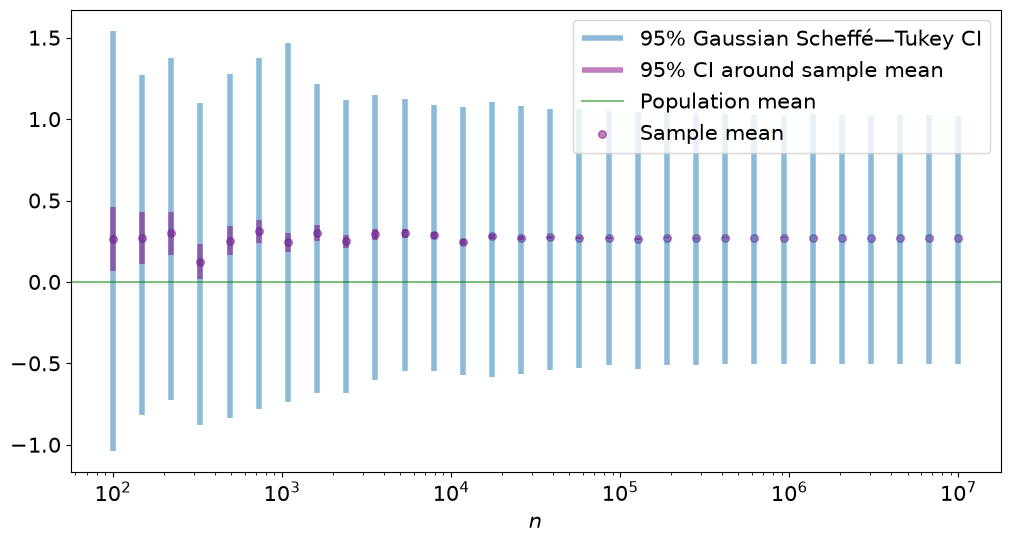

In [6]:
### Case (d), varying n

eps_1 = 0
eps_2 = 0.5
sigma_max = 2

n_list = np.logspace(2, 7, num=30, dtype=int)
fixed_eps_dict = {}
opt_up = []
opt_low = []
uppers = []
lowers = []
means = []
means_upper = []
means_lower = []

for n in n_list:
  n = int(n)
  Z = generate_truncated_samples_gaussian(n, eps_1, eps_2, level, rng)
  sim_dict = confidence_intervals.adaptive_CI_Gaussian(Z, 1, 1, alpha, sigma_max)

  uppers.append(sim_dict["right"])
  lowers.append(sim_dict["left"])
  mean = confidence_intervals.compute_sample_mean(Z)
  means.append(confidence_intervals.compute_sample_mean(Z))
  means_upper.append(mean + 1.96/np.sqrt(n))
  means_lower.append(mean - 1.96/np.sqrt(n))

plt.figure(figsize=(12,6))
plt.vlines(n_list, lowers, uppers, label=r"95% Gaussian Scheffé—Tukey CI", alpha=0.5, linewidth=4)
plt.vlines(n_list, means_lower, means_upper, label="95% CI around sample mean", color='purple', alpha=0.5,linewidth=4)
plt.axhline(0,color='green', alpha = 0.5, label="Population mean")
plt.scatter(n_list,means, color='purple', s=30, alpha = 0.5, label='Sample mean')
plt.xlabel(r"$n$", fontsize=15)
plt.legend(fontsize=15, loc="best")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.semilogx()

plt.savefig("Gaussian-d-vary-n.pdf")

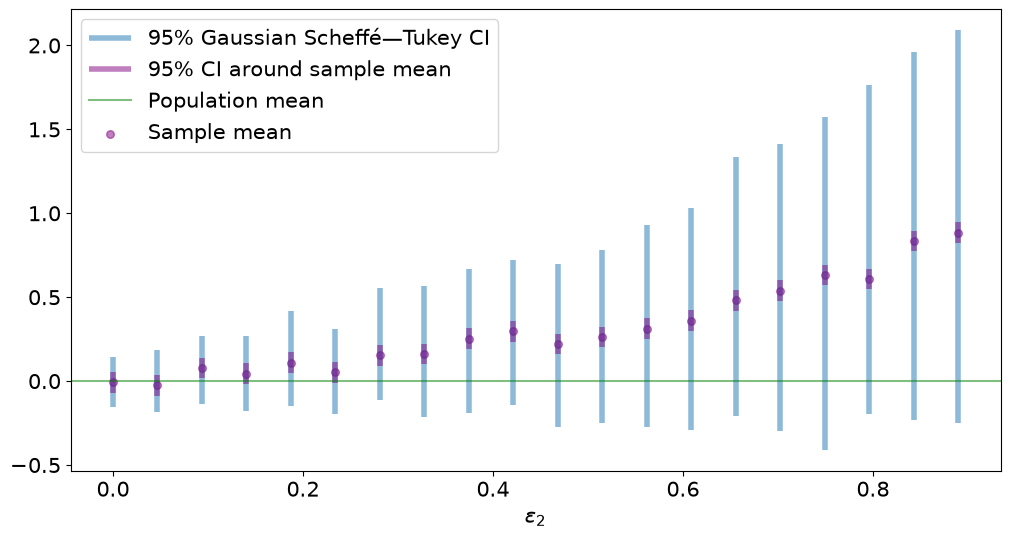

In [7]:
### Case (c), fixed n, eps_1=0.05, varying eps_2

eps_1 = 0.05
eps_2_list = np.linspace(0,0.89,20)

n = 1000
vary_eps_dict = {}
opt_up = []
opt_low = []
uppers = []
lowers = []
means = []
means_upper = []
means_lower = []
maxmin = []
for eps_2 in eps_2_list:
  Z = generate_truncated_samples_gaussian(n, eps_1, eps_2, level, rng)
  sim_dict = confidence_intervals.adaptive_CI_Gaussian(Z, 1, 1, alpha, 1)
  # opt_dict = SimulationSetting.adaptive_CI(trunc, 0.05)
  # opt_up.append(opt_dict["right"])
  # opt_low.append(opt_dict["left"])
  uppers.append(sim_dict["right"])
  lowers.append(sim_dict["left"])
  mean = confidence_intervals.compute_sample_mean(Z)
  means.append(confidence_intervals.compute_sample_mean(Z))
  means_upper.append(mean + 1.96/np.sqrt(n))
  means_lower.append(mean - 1.96/np.sqrt(n))
  maxmin.append(confidence_intervals.max_min_avg(Z))

plt.figure(figsize=(12,6))
plt.vlines(eps_2_list, lowers, uppers, label=r"95% Gaussian Scheffé—Tukey CI", alpha=0.5, linewidth=4)
plt.vlines(eps_2_list, means_lower, means_upper, label="95% CI around sample mean", color='purple', alpha=0.5,linewidth=4)
plt.axhline(0,color='green', alpha = 0.5, label="Population mean")
plt.scatter(eps_2_list,means, color='purple', s=30, alpha = 0.5, label='Sample mean')
plt.xlabel(r"$\epsilon_2$", fontsize=15)
# plt.scatter(n_list, maxmin, color='black', alpha = 0.5, label="Average of extremes")
plt.legend(loc="upper left", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.savefig("Gaussian-c-005.pdf")

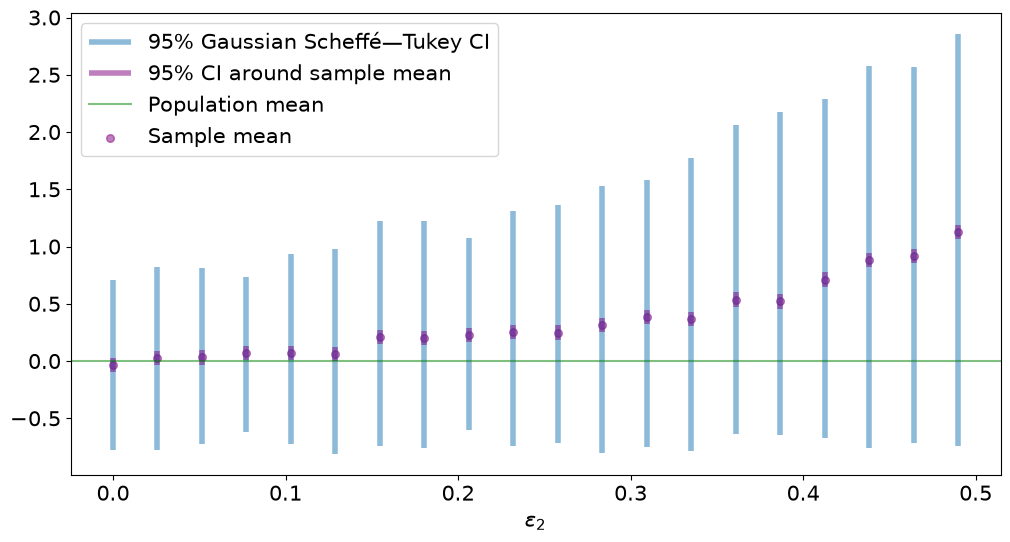

In [8]:
### Case (c), fixed n, eps_1=0.5, varying eps_2

eps_1 = 0.5
eps_2_list = np.linspace(0,0.49,20)

n = 1000
vary_eps_dict = {}
opt_up = []
opt_low = []
uppers = []
lowers = []
means = []
means_upper = []
means_lower = []
maxmin = []
for eps_2 in eps_2_list:
  Z = generate_truncated_samples_gaussian(n, eps_1, eps_2, level, rng)
  sim_dict = confidence_intervals.adaptive_CI_Gaussian(Z, 1, 1, alpha, 1)
  # opt_dict = SimulationSetting.adaptive_CI(trunc, 0.05)
  # opt_up.append(opt_dict["right"])
  # opt_low.append(opt_dict["left"])
  uppers.append(sim_dict["right"])
  lowers.append(sim_dict["left"])
  mean = confidence_intervals.compute_sample_mean(Z)
  means.append(confidence_intervals.compute_sample_mean(Z))
  means_upper.append(mean + 1.96/np.sqrt(n))
  means_lower.append(mean - 1.96/np.sqrt(n))
  maxmin.append(confidence_intervals.max_min_avg(Z))

plt.figure(figsize=(12,6))
plt.vlines(eps_2_list, lowers, uppers, label=r"95% Gaussian Scheffé—Tukey CI", alpha=0.5, linewidth=4)
plt.vlines(eps_2_list, means_lower, means_upper, label="95% CI around sample mean", color='purple', alpha=0.5,linewidth=4)
plt.axhline(0,color='green', alpha = 0.5, label="Population mean")
plt.scatter(eps_2_list,means, color='purple', s=30, alpha = 0.5, label='Sample mean')
plt.xlabel(r"$\epsilon_2$", fontsize=15)
# plt.scatter(n_list, maxmin, color='black', alpha = 0.5, label="Average of extremes")
plt.legend(loc="upper left", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.savefig("Gaussian-c-05.pdf")

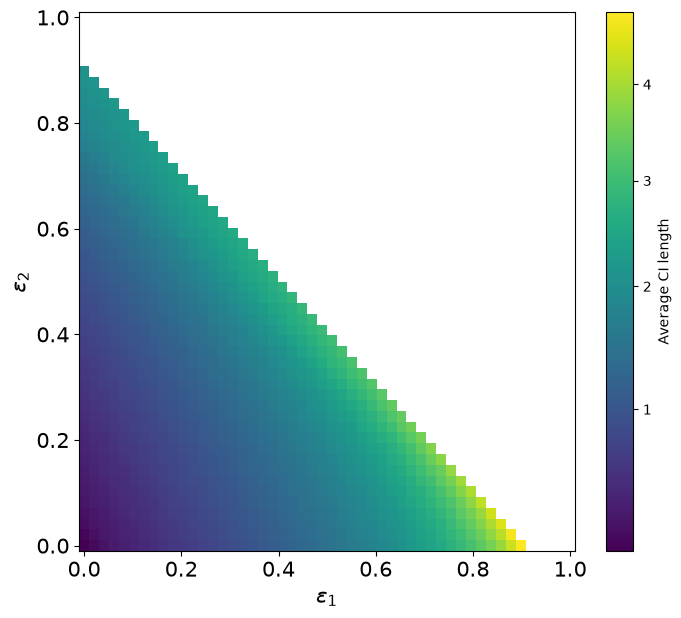

In [17]:
### Case (c), heatmap of average CI length

n_rep = 100
n = 1000

grid = np.linspace(0, 1, 50)

eps_grid = [
    (eps_1, eps_2)
    for eps_1 in grid
    for eps_2 in grid
    if eps_1 + eps_2 <= 0.9
]

from joblib import Parallel, delayed

def compute_average_length(eps_1, eps_2, seed):
    rng_local = np.random.default_rng(seed)

    total_length = 0.0

    for _ in range(n_rep):
        Z = generate_truncated_samples_gaussian(n, eps_1, eps_2, level, rng_local)

        sim_dict = confidence_intervals.adaptive_CI_Gaussian(Z, 1, 1, alpha, 1)

        total_length += sim_dict["right"] - sim_dict["left"]

    return (eps_1, eps_2), total_length / n_rep


seed_seq = np.random.SeedSequence(42)
child_seeds = seed_seq.spawn(len(eps_grid))

results = Parallel(n_jobs=-1)(
    delayed(compute_average_length)(
        eps_1,
        eps_2,
        child_seed,
    )
    for (eps_1, eps_2), child_seed in zip(eps_grid, child_seeds)
)

lengths = dict(results)

length_matrix = np.full((len(grid), len(grid)), np.nan)

for (eps_1, eps_2), value in lengths.items():
    i = np.argmin(np.abs(grid - eps_1))
    j = np.argmin(np.abs(grid - eps_2))
    length_matrix[j, i] = value

plt.figure(figsize=(8, 7))

from matplotlib.colors import LogNorm, PowerNorm

plt.pcolormesh(
    grid,
    grid,
    length_matrix,
    shading="auto",
    norm=PowerNorm(gamma=0.75),
    cmap="viridis"
)

plt.colorbar(label="Average CI length")

plt.xlabel(r"$\varepsilon_1$", fontsize=15)
plt.ylabel(r"$\varepsilon_2$", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.savefig('Gaussian-c-heatmap.pdf')

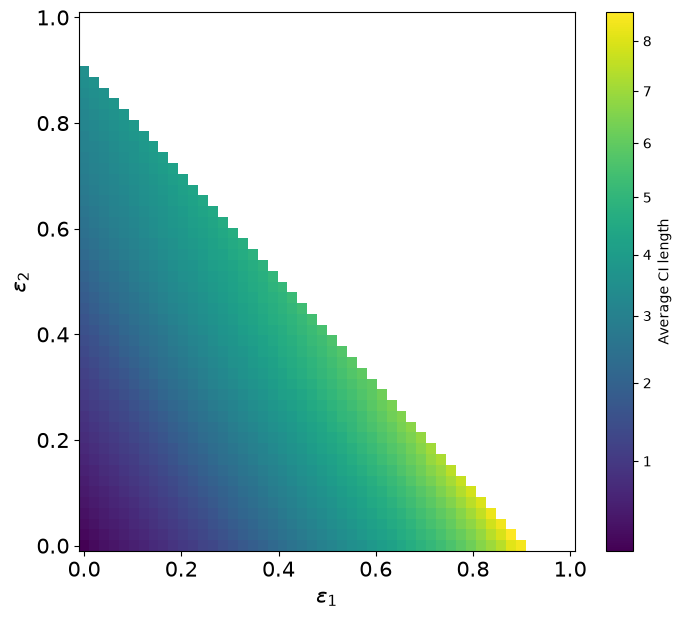

In [18]:
### Case (d), heatmap of average CI length

n_rep = 100
n = 1000
sigma_max = 2

grid = np.linspace(0, 1, 50)

eps_grid = [
    (eps_1, eps_2)
    for eps_1 in grid
    for eps_2 in grid
    if eps_1 + eps_2 <= 0.9
]

from joblib import Parallel, delayed

def compute_average_length(eps_1, eps_2, seed):
    rng_local = np.random.default_rng(seed)

    total_length = 0.0

    for _ in range(n_rep):
        Z = generate_truncated_samples_gaussian(n, eps_1, eps_2, level, rng_local)

        sim_dict = confidence_intervals.adaptive_CI_Gaussian(Z, 1, 1, alpha, sigma_max)

        total_length += sim_dict["right"] - sim_dict["left"]

    return (eps_1, eps_2), total_length / n_rep


seed_seq = np.random.SeedSequence(42)
child_seeds = seed_seq.spawn(len(eps_grid))

results = Parallel(n_jobs=-1)(
    delayed(compute_average_length)(
        eps_1,
        eps_2,
        child_seed,
    )
    for (eps_1, eps_2), child_seed in zip(eps_grid, child_seeds)
)

lengths = dict(results)

length_matrix = np.full((len(grid), len(grid)), np.nan)

for (eps_1, eps_2), value in lengths.items():
    i = np.argmin(np.abs(grid - eps_1))
    j = np.argmin(np.abs(grid - eps_2))
    length_matrix[j, i] = value

plt.figure(figsize=(8, 7))

from matplotlib.colors import LogNorm, PowerNorm

plt.pcolormesh(
    grid,
    grid,
    length_matrix,
    shading="auto",
    norm=PowerNorm(gamma=0.75),
    cmap="viridis"
)

plt.colorbar(label="Average CI length")

plt.xlabel(r"$\varepsilon_1$", fontsize=15)
plt.ylabel(r"$\varepsilon_2$", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.savefig('Gaussian-d-heatmap.pdf')